In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from url_phishing_classification.eda import (
    deduplication_stats,
    plot_binary_indicators_by_label,
    plot_character_and_structure_eda,
    plot_entropy_distributions_by_label,
    plot_length_and_component_eda,
    plot_port_distribution_by_label,
    plot_quantile_risk_curves,
    plot_scheme_and_suffix_patterns,
    plot_spearman_families,
    plot_tail_ecdfs_by_label,
    review_extreme_urls,
    signal_prevalence_reports,
    summarize_high_spearman_pairs,
    summarize_numeric_features_by_label,
    summarize_parsed_text_sparsity,
)
from url_phishing_classification.preprocessing import deduplicate_urls, engineer_features, normalize_url

## Config

In [3]:
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_columns", None)

In [4]:
DATA_PATH = Path("../data/train.csv")

## Read data, deduplicate and create features

Deduplication is done in the preprocess.py file too, this is included here to show the conflicts before it

In [5]:
df = pd.read_csv(DATA_PATH)

In [6]:
df["normalized_url"] = df["url"].fillna("").astype(str).map(normalize_url)

In [7]:
deduplication_stats(df)

,duplicate_rows,rows_in_conflicting_groups,conflicting_groups
url_type,,,
original,80,100,50
normalized,276,107,50


276 duplicate rows after normalization. 50 cases where the labels are different, in this none of them are kept, in simple duplication first occurance is kept

In [8]:
df.shape

(8651, 3)

In [9]:
df = deduplicate_urls(df, label_column="label")

In [10]:
df.shape

(8325, 3)

In [11]:
df = engineer_features(df, url_column="url")

In [12]:
df

,url,label,normalized_url,domain,subdomain,suffix,registered_domain,scheme,is_http,hostname,path,query,fragment,params,query_parameters,has_query,has_fragment,has_params,subdomain_labels,no_host,is_ip_literal_host,host_label_count,has_port,port,unusual_port,has_malformed_port,path_segment_count,dot_count,hyphen_count,slash_count,underscore_count,equals_count,ampersand_count,non_alphanumeric_count,digit_ratio,url_letter_ratio,url_non_alphanumeric_ratio,has_at,has_percent_encoding,has_punycode,has_unicode,has_repeated_separator,double_slash_in_path,has_shortening_service,has_redirect_keyword,has_suspicious_keyword,has_suspicious_tld,host_digit_ratio,host_letter_ratio,path_digit_ratio,path_letter_ratio,query_digit_ratio,query_letter_ratio,url_entropy,url_norm_entropy,url_length,hostname_entropy,hostname_norm_entropy,hostname_length,domain_entropy,domain_norm_entropy,domain_length,subdomain_entropy,subdomain_norm_entropy,subdomain_length,path_entropy,path_norm_entropy,path_length,query_entropy,query_norm_entropy,query_length,fragment_entropy,fragment_norm_entropy,fragment_length
0,http://memory-beta.wikia.com/wiki/Commander,0,memory-beta.wikia.com/wiki/commander,wikia,memory-beta,com,wikia.com,http,True,memory-beta.wikia.com,/wiki/Commander,,,,0,False,False,False,1,False,False,3,False,0,False,False,2,2,1,4,0,0,0,8,0.000000,0.813953,0.186047,False,False,False,False,True,False,False,False,False,False,0.0,0.857143,0.000000,0.866667,0.00,0.000000,4.155818,0.946156,43,3.689704,0.969099,21,1.921928,0.960964,5,3.095795,0.976615,11,3.506891,0.978222,15,0.000000,0.000000,0,0.0,0.0,0
1,https://www.highspeedinternet.com/wa/seattle,0,highspeedinternet.com/wa/seattle,highspeedinternet,www,com,highspeedinternet.com,https,False,www.highspeedinternet.com,/wa/seattle,,,,0,False,False,False,1,False,False,3,False,0,False,False,2,2,0,4,0,0,0,7,0.000000,0.840909,0.159091,False,False,False,False,True,False,False,False,False,False,0.0,0.920000,0.000000,0.818182,0.00,0.000000,3.947402,0.929253,44,3.733661,0.955660,25,3.146286,0.947127,17,0.000000,0.000000,3,2.732159,0.973215,11,0.000000,0.000000,0,0.0,0.0,0
2,http://www.tutorialspoint.com/computer_fundamentals/computer_memory.htm,0,tutorialspoint.com/computer_fundamentals/computer_memory.htm,tutorialspoint,www,com,tutorialspoint.com,http,True,www.tutorialspoint.com,/computer_fundamentals/computer_memory.htm,,,,0,False,False,False,1,False,False,3,False,0,False,False,2,3,0,4,2,0,0,10,0.000000,0.859155,0.140845,False,False,False,False,True,False,False,False,False,False,0.0,0.909091,0.000000,0.880952,0.00,0.000000,4.213620,0.944878,71,3.629220,0.953213,22,3.182006,0.957879,14,0.000000,0.000000,3,4.016736,0.945575,42,0.000000,0.000000,0,0.0,0.0,0
3,https://drive.google.com/file/d/1ik3UxH3RDigwAr7D269WVkoWp17Cci1n/edit,1,drive.google.com/file/d/1ik3uxh3rdigwar7d269wvkowp17cci1n/edit,google,drive,com,google.com,https,False,drive.google.com,/file/d/1ik3UxH3RDigwAr7D269WVkoWp17Cci1n/edit,,,,0,False,False,False,1,False,False,3,False,0,False,False,4,2,0,6,0,0,0,9,0.142857,0.728571,0.128571,False,False,False,False,True,False,False,False,True,False,0.0,0.875000,0.217391,0.695652,0.00,0.000000,4.900153,0.947819,70,3.327820,0.961956,16,1.918296,0.959148,6,2.321928,1.000000,5,4.689550,0.955707,46,0.000000,0.000000,0,0.0,0.0,0
4,https://app.box.com/s/b9fu9axf9rcv7bhjp80fpcm8zna5wcwi,1,app.box.com/s/b9fu9axf9rcv7bhjp80fpcm8zna5wcwi,box,app,com,box.com,https,False,app.box.com,/s/b9fu9axf9rcv7bhjp80fpcm8zna5wcwi,,,,0,False,False,False,1,False,False,3,False,0,False,False,2,2,0,4,0,0,0,7,0.148148,0.722222,0.12963,False,False,False,False,True,False,False,False,False,False,0.0,0.818182,0.228571,0.714286,0.00,0.000000,4.558051,0.958603,54,2.913977,0.971326,11,1.584963,1.000000,3,0.918296,0.918296,3,4.378864,0.968012,35,0.000000,0.000000,0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

## Check for NAs

In [13]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

No NAs in feature cols to be used for modeling

## URL keyword and domain-signal

In [14]:
signal_prevalence_report, term_prevalence_report = signal_prevalence_reports(df)
display(signal_prevalence_report)
display(term_prevalence_report.sort_values(["signal", "matched_urls"], ascending=[True, False]))

,feature,matched_urls,prevalence_pct,label_1_pct
0,has_shortening_service,16,0.19,100.00
1,has_redirect_keyword,261,3.14,65.90
2,has_suspicious_keyword,1368,16.43,90.13
3,has_suspicious_tld,73,0.88,95.89


,term,matched_urls,label_1_pct,signal,prevalence_pct
8,link,142,69.72,redirect_keyword,1.71
7,url,61,54.10,redirect_keyword,0.73
6,redirect,41,75.61,redirect_keyword,0.49
10,away,8,100.00,redirect_keyword,0.10
9,goto,1,0.00,redirect_keyword,0.01
0,bit.ly,13,100.00,shortening_service,0.16
1,tinyurl.com,3,100.00,shortening_service,0.04
2,short.link,0,0.00,shortening_service,0.00
3,ow.ly,0,0.00,shortening_service,0.00
4,t.co,0,0.00,shortening_service,0.00


Dropped "out" from redirect keywords, it was more common in benign URLS (only 39.22% was phishing)

has_suspicious_keyword is a strong and rather common signal, has_shortening_service and has_suspicious_tld is also good signal but only small percentage of urls have them

## Length and component-presence features

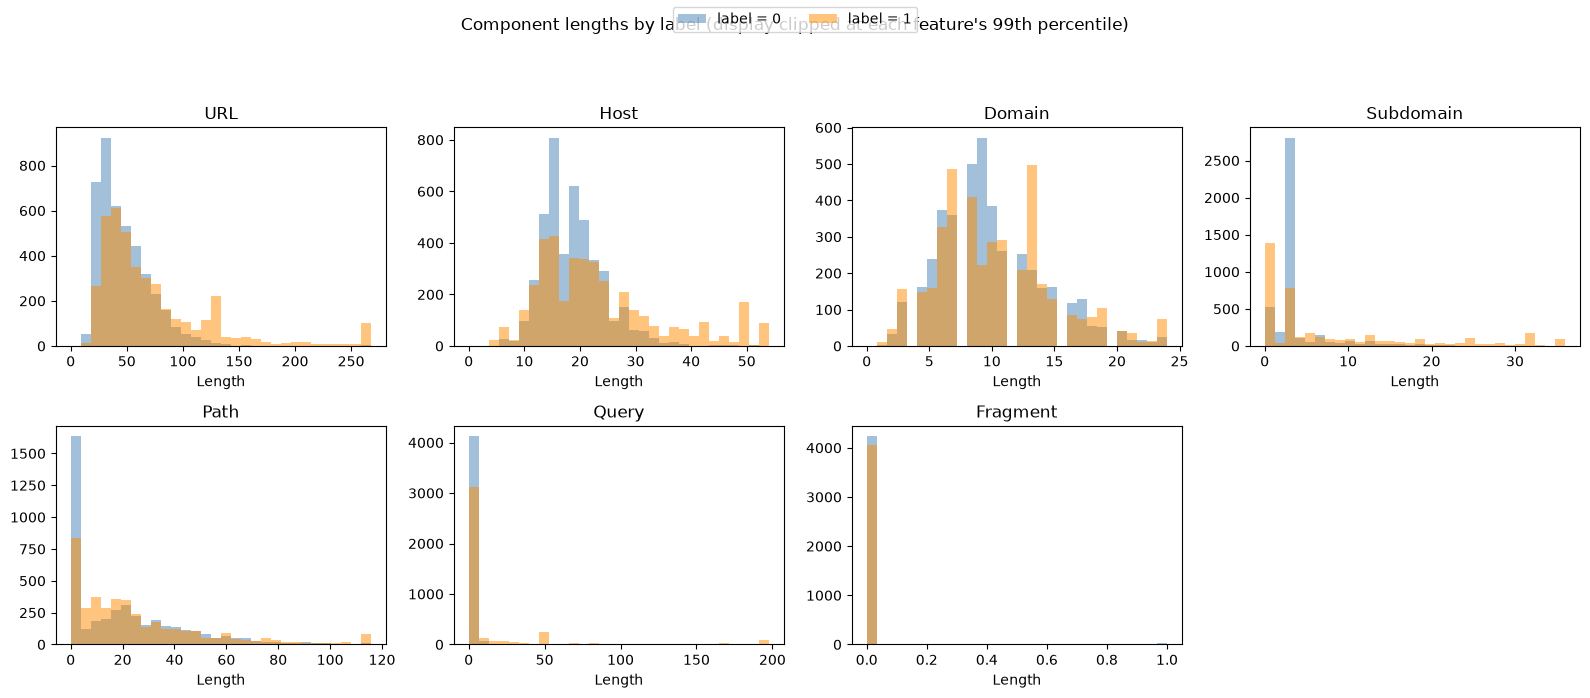

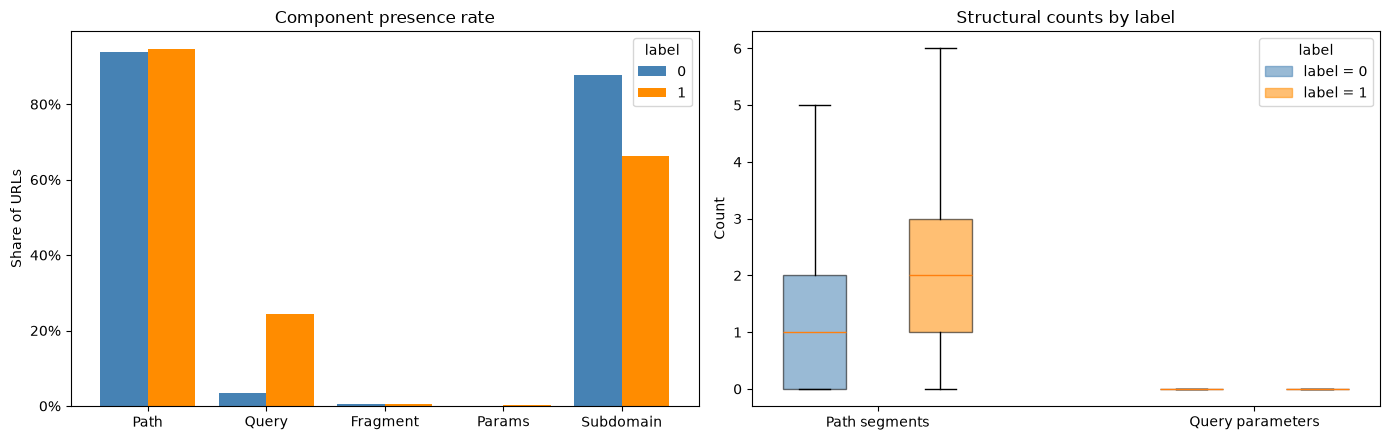

In [15]:
plot_length_and_component_eda(df)
plt.show()

## Character composition and URL structure

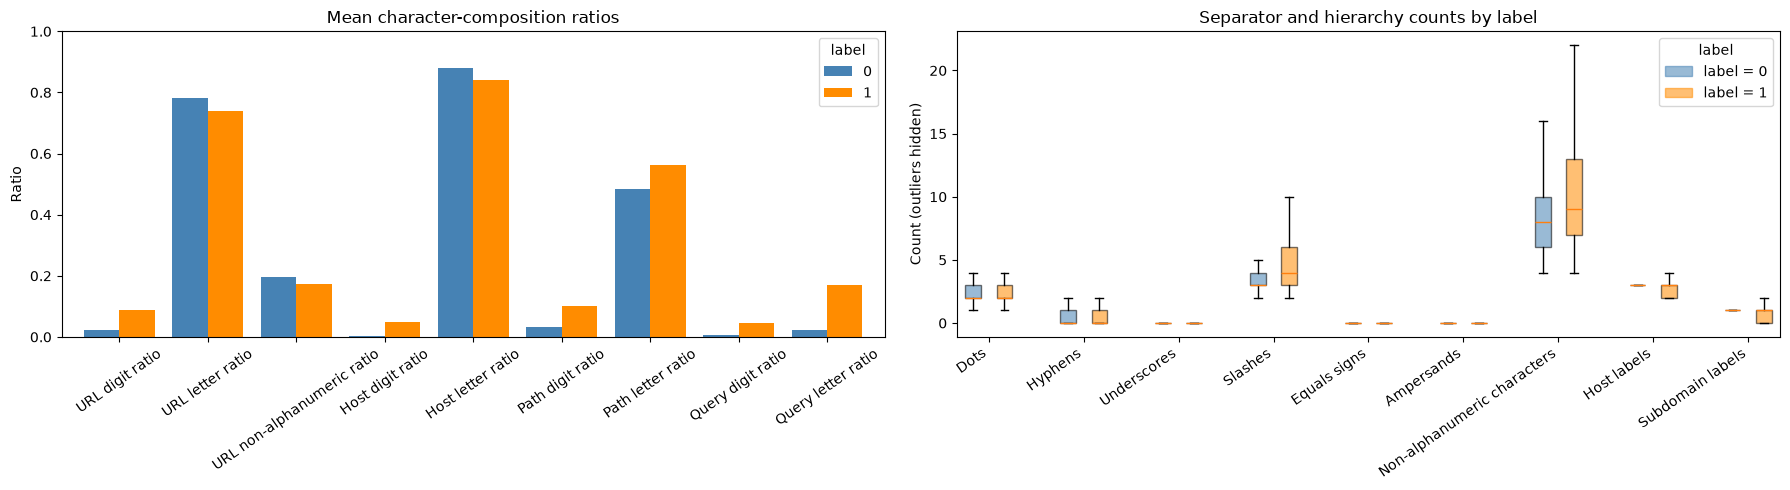

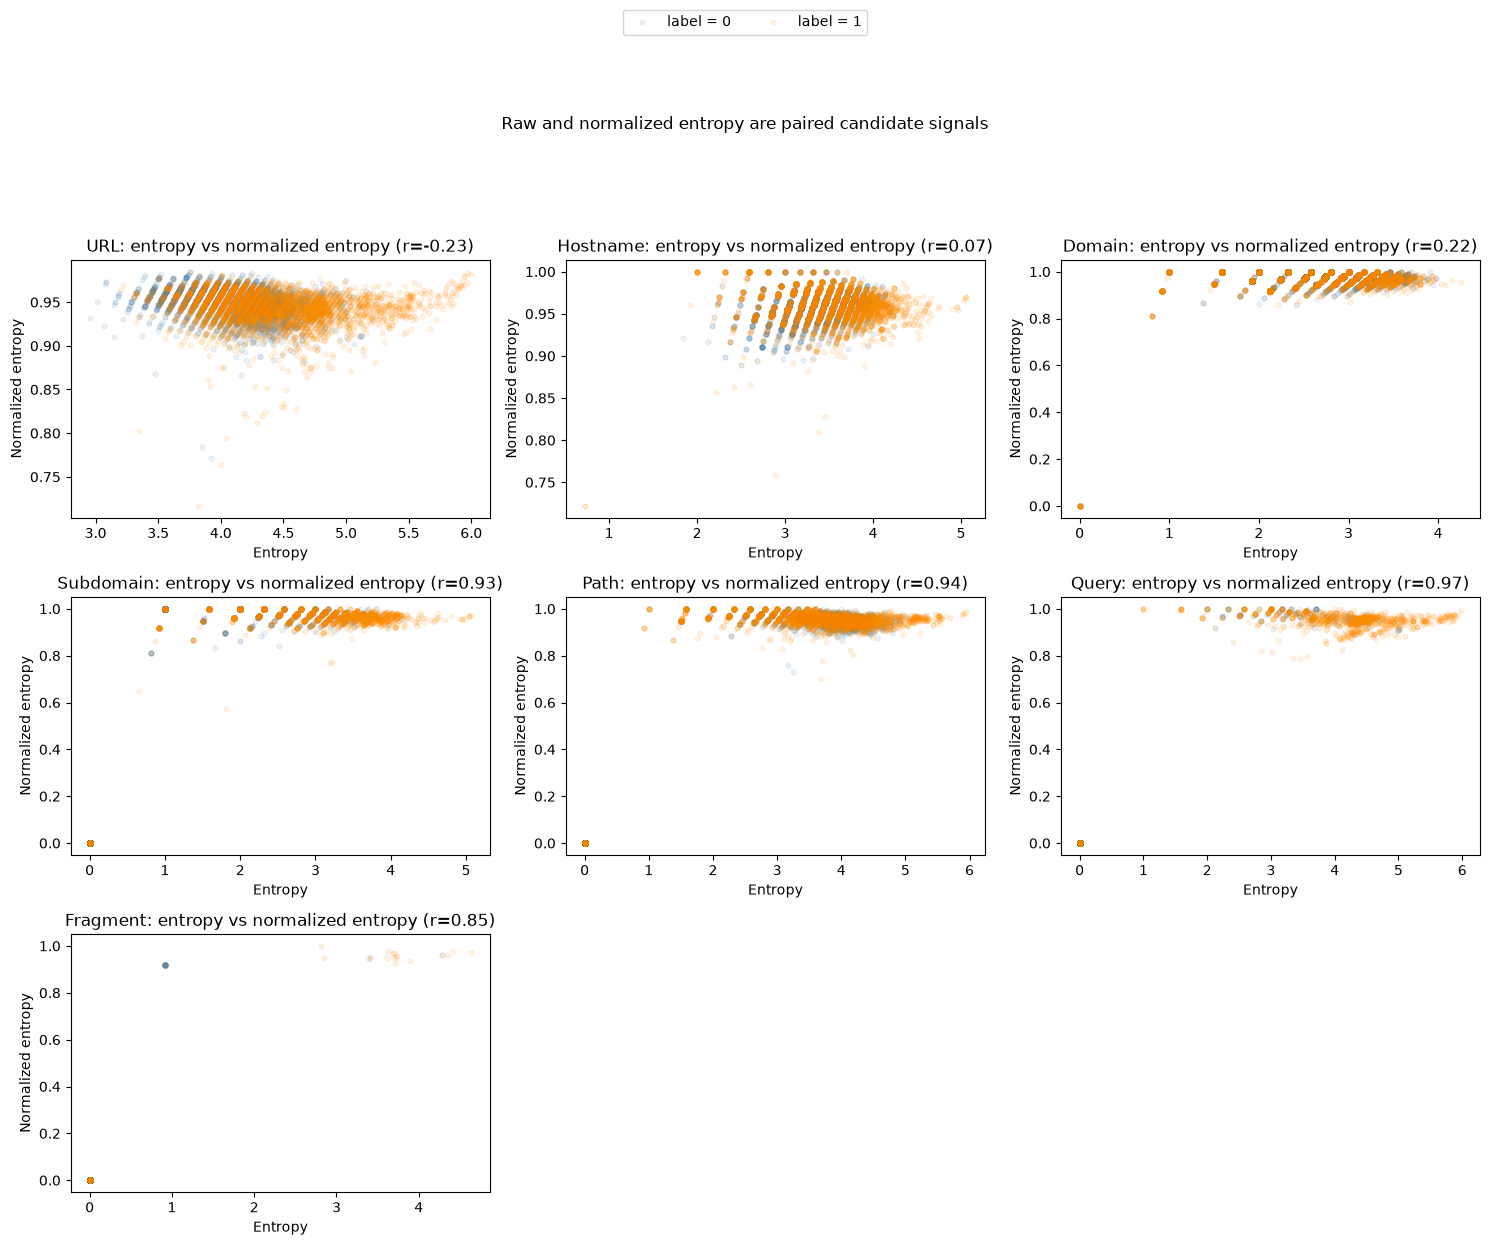

In [16]:
plot_character_and_structure_eda(df)
plt.show()

Slashes and non-alphanum chars can also be good signals

Based on these it seems like that non-normalized entropy might be more useful to separate the two labels, this is most prevalent in URL. But both types of entropy seem to capture essentially the same thing

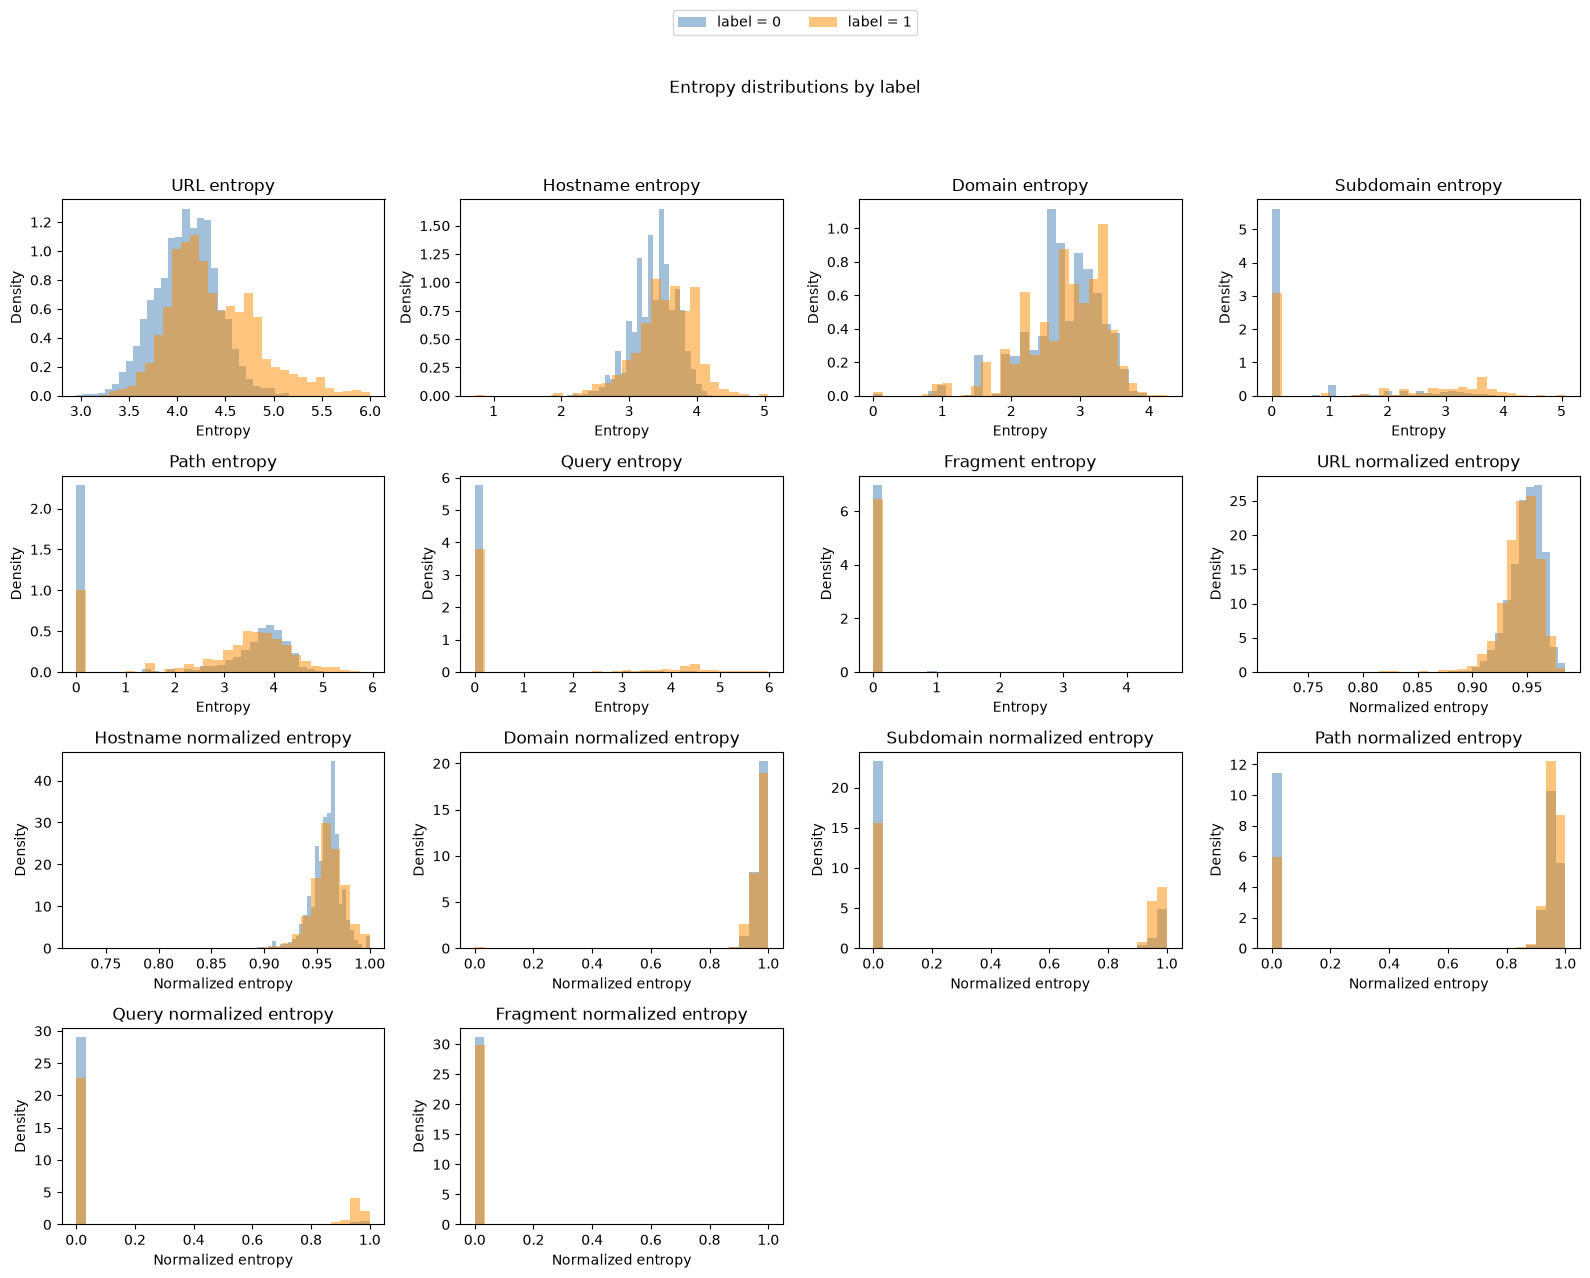

In [17]:
plot_entropy_distributions_by_label(df)
plt.show()

I expected URL entropy and entropy of the components in general to have a higher difference between phishing and non-phishing emails

## Structural indicators and descriptive patterns

In [18]:
numeric_feature_summary = summarize_numeric_features_by_label(df)
numeric_feature_summary

median   mean  iqr  p90  p95  missing_rate  \
feature               label                                               
is_http               0         1.0  0.560  1.0  1.0  1.0           0.0   
                      1         1.0  0.667  1.0  1.0  1.0           0.0   
query_parameters      0         0.0  0.060  0.0  0.0  0.0           0.0   
                      1         0.0  0.550  0.0  3.0  3.0           0.0   
has_query             0         0.0  0.034  0.0  0.0  0.0           0.0   
...                             ...    ...  ...  ...  ...           ...   
fragment_entropy      1         0.0  0.016  0.0  0.0  0.0           0.0   
fragment_norm_entropy 0         0.0  0.005  0.0  0.0  0.0           0.0   
                      1         0.0  0.004  0.0  0.0  0.0           0.0   
fragment_length       0         0.0  0.026  0.0  0.0  0.0           0.0   
                      1         0.0  0.100  0.0  0.0  0.0           0.0   

                             zero_rate  
feature               label             
is_http               0          0.440  
                      1          0.333  
query_parameters      0          0.966  
                      1          0.755  
has_query             0          0.966  
...                                ...  
fragment_entropy      1          0.996  
fragment_norm_entropy 0          0.995  
                      1          0.996  
fragment_length       0          0.995  
                      1          0.996  

[122 rows x 7 columns]

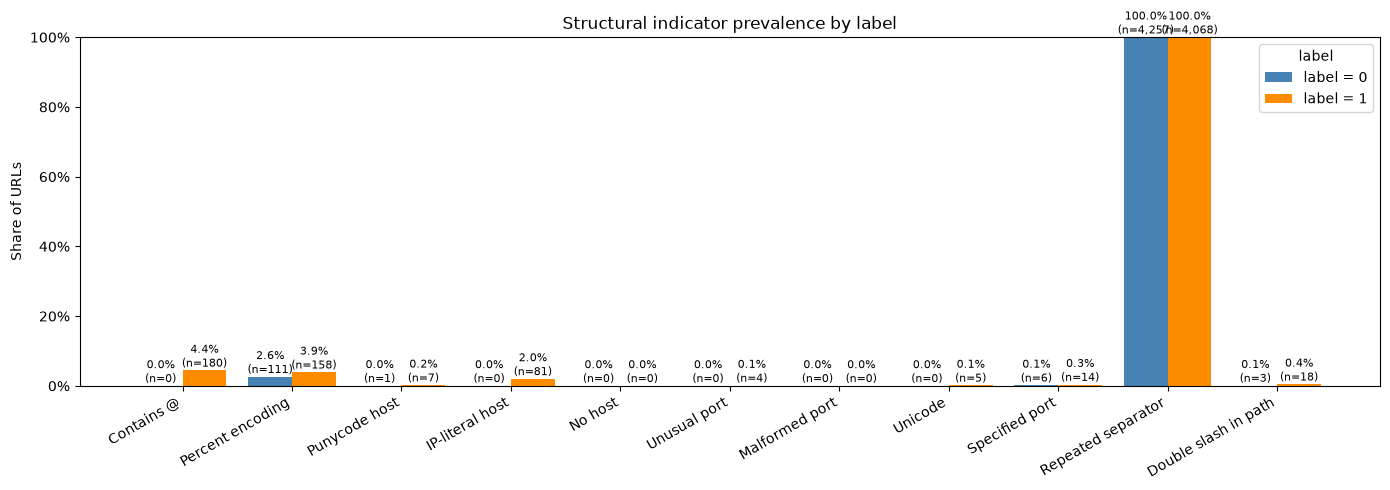

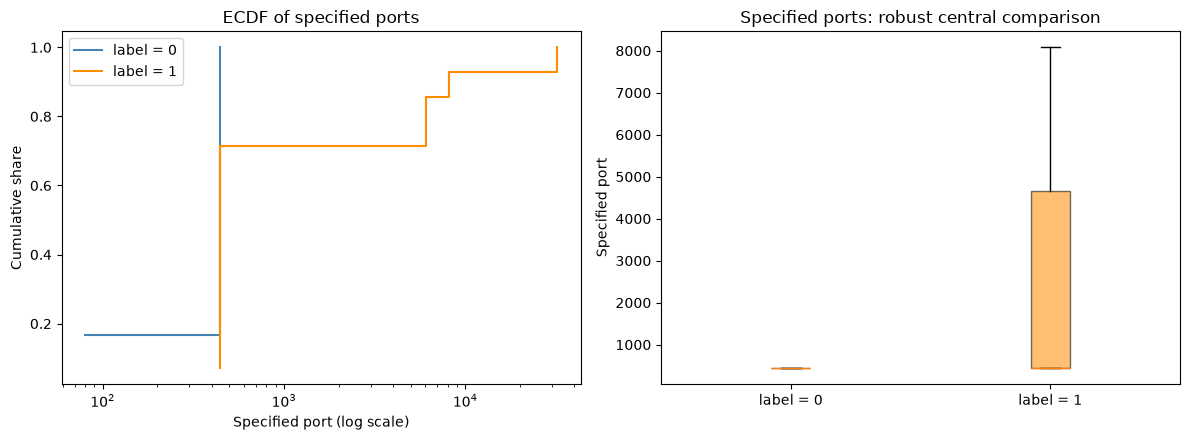

In [19]:
plot_binary_indicators_by_label(df)
plot_port_distribution_by_label(df)
plt.show()

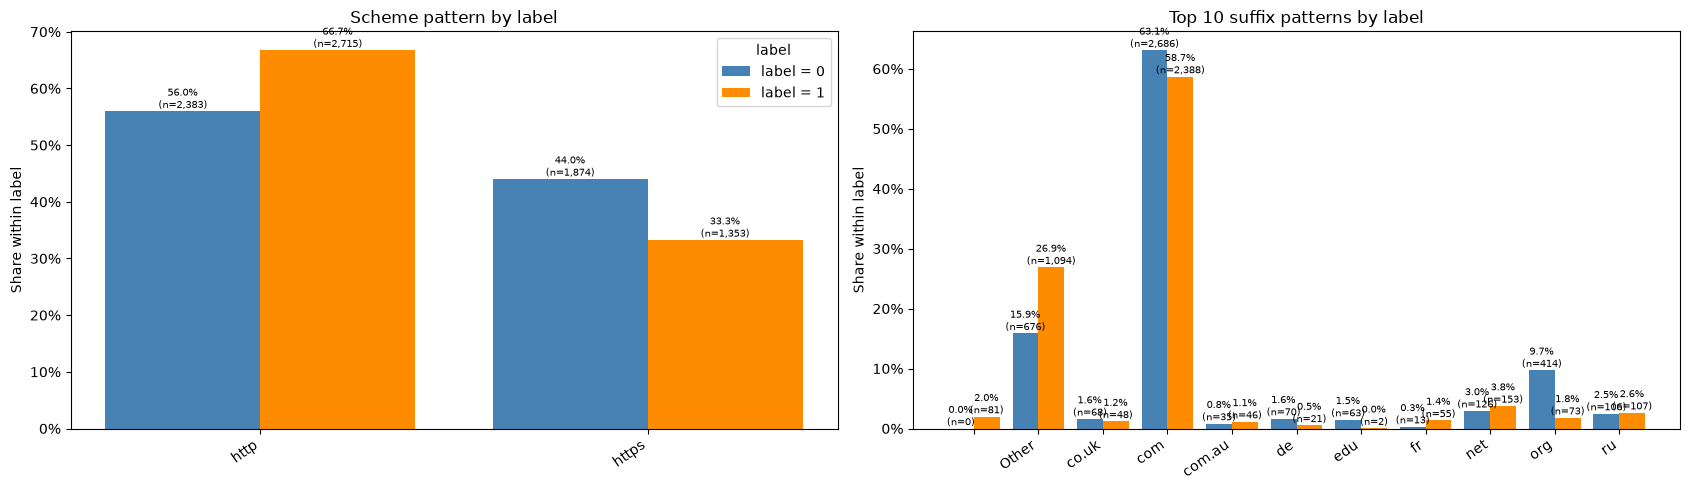

In [20]:
plot_scheme_and_suffix_patterns(df)
plt.show()

In [21]:
# TODO: maybe create new feature with top 10 suffix patterns??

## Missingness, sparsity, and tail review

Parsed text fields use an empty string when the component is absent. Their absence is retained through explicit presence indicators, rather than being treated as ordinary lexical content. Extreme URLs are reviewed as audit records only; raw URLs and domains remain excluded from model features.


In [22]:
parsed_text_sparsity = summarize_parsed_text_sparsity(df)
parsed_text_sparsity

rows  empty_string_rate  missing_rate  presence_rate
component label                                                      
Query     0      4257              0.966           0.0          0.034
          1      4068              0.755           0.0          0.245
Fragment  0      4257              0.995           0.0          0.005
          1      4068              0.996           0.0          0.004
Params    0      4257              1.000           0.0          0.000
          1      4068              0.997           0.0          0.003

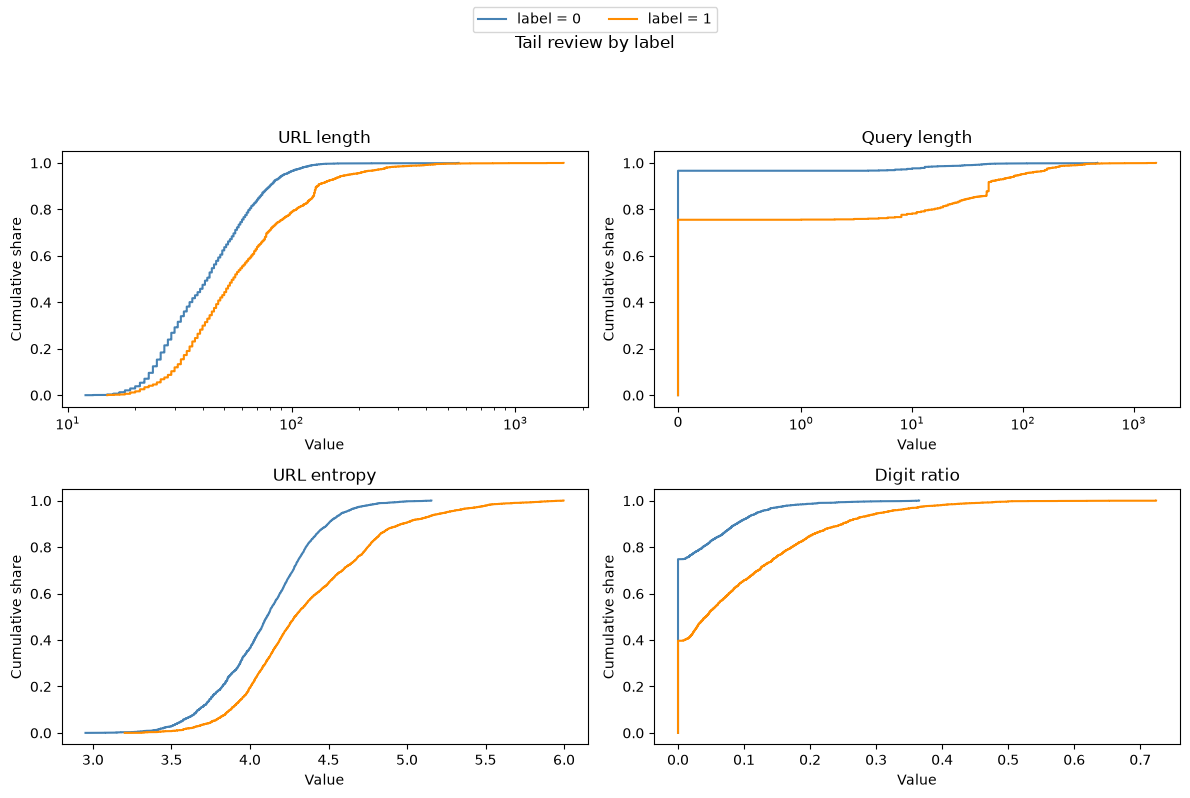

,review_feature,label,url,scheme,hostname,query,fragment,params,no_host,has_malformed_port,feature_value
80,Ampersands,0,https://www.nextmillenniumcatalog.com/Responsive/ApplyStepOneNS.aspx?sfid=4&ns=wax-2&nscpa=1&crp=rh&oid=270&tid=f030c1da239a4706935f3a5ed135a2a4&aid=501783&...,https,www.nextmillenniumcatalog.com,sfid=4&ns=wax-2&nscpa=1&crp=rh&oid=270&tid=f030c1da239a4706935f3a5ed135a2a4&aid=501783&c1=&c2=&c3=&email=&first=&last=&address=&zip=&hphone1=&hphone2=&hphone3=,,,False,False,17.0
81,Ampersands,0,https://login.microsoftonline.com/dc046083-4ce8-437a-bd49-e995b65e4d11/oauth2/authorize?client_id=00000003-0000-0ff1-ce00-000000000000&response_mode=form_po...,https,login.microsoftonline.com,client_id=00000003-0000-0ff1-ce00-000000000000&response_mode=form_post&response_type=code%20id_token&resource=00000003-0000-0ff1-ce00-000000000000&scope=ope...,,,False,False,9.0
82,Ampersands,0,https://login.microsoftonline.com/decee90c-ce03-461e-8c21-dd538e181c75/oauth2/authorize?client_id=00000003-0000-0ff1-ce00-000000000000&response_mode=form_po...,https,login.microsoftonline.com,client_id=00000003-0000-0ff1-ce00-000000000000&response_mode=form_post&response_type=code%20id_token&resource=00000003-0000-0ff1-ce00-000000000000&scope=ope...,,,False,False,9.0
83,Ampersands,0,https://login.microsoftonline.com/9024fef9-acd7-4a9a-98d1-b7225b67cf24/oauth2/authorize?client_id=00000003-0000-0ff1-ce00-000000000000&response_mode=form_po...,https,login.microsoftonline.com,client_id=00000003-0000-0ff1-ce00-000000000000&response_mode=form_post&response_type=code%20id_token&resource=00000003-0000-0ff1-ce00-000000000000&scope=ope...,,,False,False,9.0
84,Ampersands,0,https://login.microsoftonline.com/abe32f68-c72d-420d-b5bd-750c63a268e4/oauth2/authorize?client_id=00000003-0000-0ff1-ce00-000000000000&response_mode=form_po...,https,login.microsoftonline.com,client_id=00000003-0000-0ff1-ce00-000000000000&response_mode=form_post&response_type=code%20id_token&resource=00000003-0000-0ff1-ce00-000000000000&scope=ope...,,,False,False,9.0
...,...,...,...,...,...,...,...,...,...,...,...
5,URL length,1,https://dev.seatassignmate.net/latam/payment_onsite.php?data=OSJDiYvam7d2RdxBW6THtDnUSa386QBYQsC-YwclMVm8LSB47xP0KqlfoUSy7HwxZXHYfOJIuLss7Ja6pBQp40Ai7J-G2z1...,https,dev.seatassignmate.net,data=OSJDiYvam7d2RdxBW6THtDnUSa386QBYQsC-YwclMVm8LSB47xP0KqlfoUSy7HwxZXHYfOJIuLss7Ja6pBQp40Ai7J-G2z1PnlajIVIwGEuiNWWlN5cowtkXv2KUfEkICym6Fp7HA3PAiakjTnRbWiH...,,,False,False,1641.0
6,URL length,1,http://licogi18.com.vn/login.microsoftonline.com/login.php?tes.php?https://login.live.com/GetSessionState.srf?response_type=code&client_id=51483342-085c-4d8...,http,licogi18.com.vn,tes.php?https://login.live.com/GetSessionState.srf?response_type=code&client_id=51483342-085c-4d86-bf88-cf50c7252078&scope=openid+profile+email+offline_acce...,,,False,False,1386.0
7,URL length,1,http://licogi18.com.vn/login.microsoftonline.com/login.php?tes.php?https://login.live.com/GetSessionState.srf?response_type=code&client_id=51483342-085c-4d8...,http,licogi18.com.vn,tes.php?https://login.live.com/GetSessionState.srf?response_type=code&client_id=51483342-085c-4d86-bf88-cf50c7252078&scope=openid+profile+email+offline_acce...,,,False,False,1386.0
8,URL length,1,http://systemupdatingserverservice.secureonlineaccessupdate.com/Chase/home/auth/Confirmed.php?Fetch=3d3d3d3d3d3d3d3d3d3d3d3d3d3d3d3d3d3d2b5b205573657220496e...,http,systemupdatingserverservice.secureonlineaccessupdate.com,Fetch=3d3d3d3d3d3d3d3d3d3d3d3d3d3d3d3d3d3d2b5b205573657220496e666f202d2043686173652052655a756c7a205d2b3d3d3d3d3d3d3d3d3d3d3d3d3d3d3d3d3d3d0d0a55736572494420...,,,False,False,938.0


In [23]:
plot_tail_ecdfs_by_label(df)
plt.show()
extreme_url_review = review_extreme_urls(df)
extreme_url_review

## Feature redundancy and baseline feature selection

Spearman correlation is used here to interpret related feature families and form a compact baseline, not as an automatic selection rule. The baseline deliberately excludes raw URL, host, domain, and registered-domain identities.


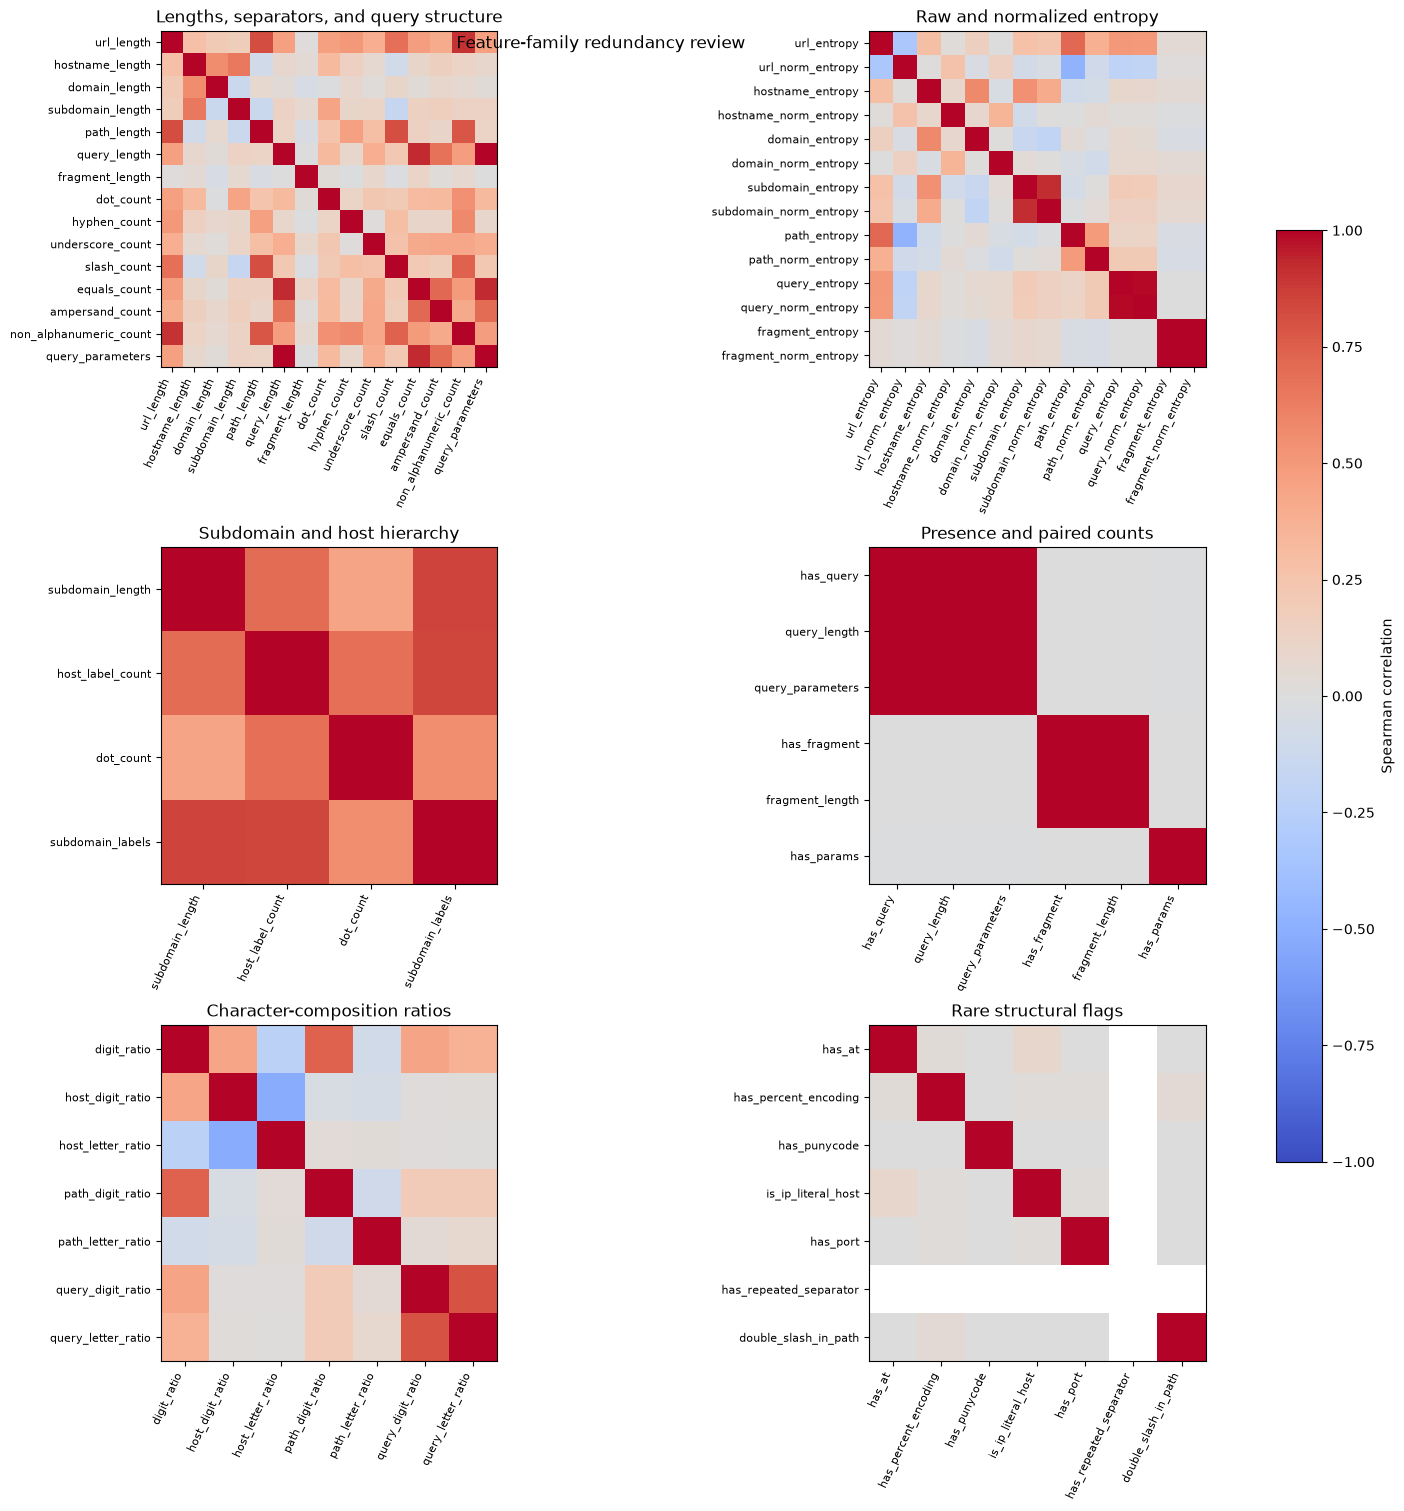

,feature_1,feature_2,spearman_rho
18,fragment_length,fragment_entropy,1.000
42,fragment_entropy,fragment_norm_entropy,1.000
19,fragment_length,fragment_norm_entropy,1.000
20,fragment_length,has_fragment,1.000
43,fragment_entropy,has_fragment,1.000
44,fragment_norm_entropy,has_fragment,1.000
13,query_length,query_entropy,0.998
12,query_length,query_parameters,0.998
31,query_parameters,has_query,0.997
15,query_length,has_query,0.996


In [24]:
strong_spearman_pairs = summarize_high_spearman_pairs(df)
plot_spearman_families(df)
plt.show()
strong_spearman_pairs

Feature selection decisions (based on all above analysis)
- only keep has_fragment -> perfect corr with other fragment features
- drop query_length and query_parameters -> highly correlated with has_query
- drop port, has_port, unusual_port, has_malformed_port -> extremly sparse features
- drop has_unicode feature -> extremly sparse
- has_repeated_separator -> all urls do
- dot and hyphen count -> no meaningful difference in dist between classes
- double_slash_in_path -> extermly sparse 

## Risk curves for continuous features

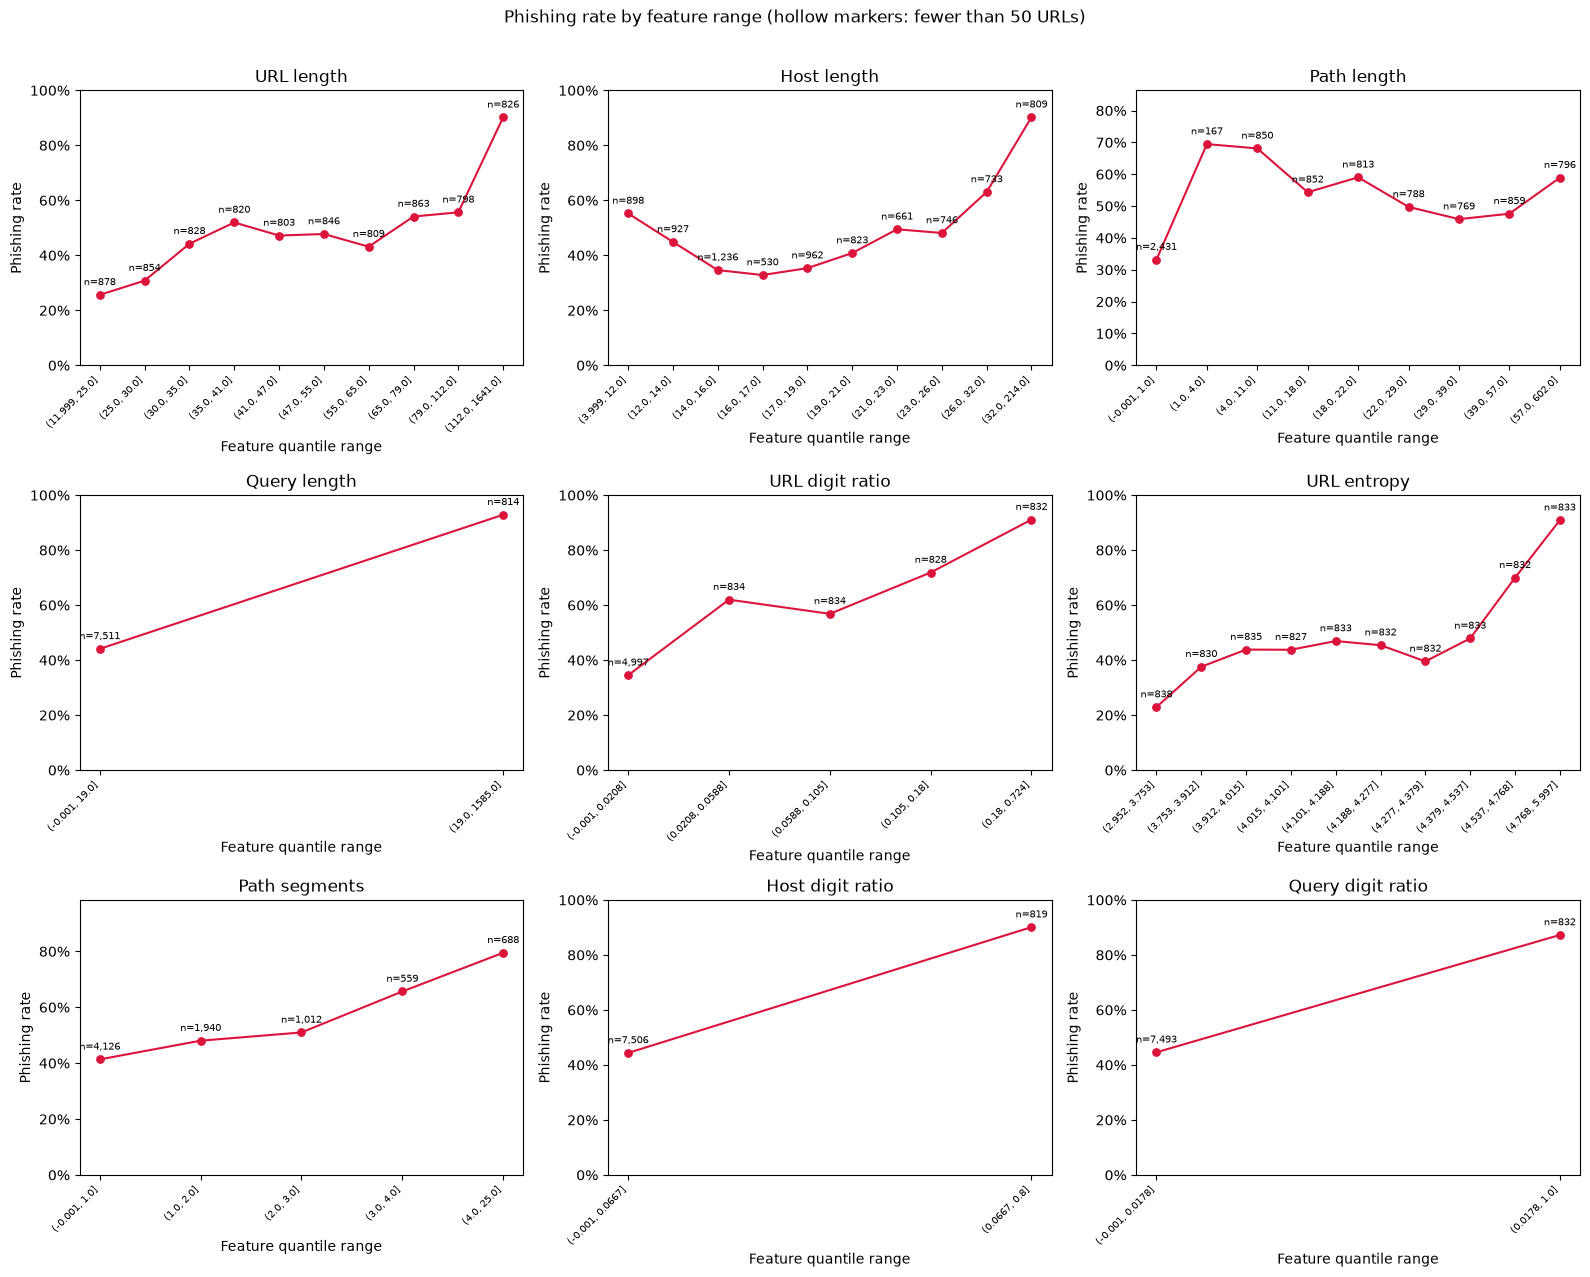

In [26]:
risk_fig, risk_curve_summary = plot_quantile_risk_curves(df)
plt.show()